In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

#폰트 설정(없으면 영문으로 나옴)
plt.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False

try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [2]:
funnel = pd.read_csv('./funnel_instance.csv')
eda = pd.read_csv('./final_eda.csv')

In [3]:
print(funnel.columns.tolist())
print(eda.columns.tolist())

['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id', 'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count', 'view_ambiguous', 't_completed', 'last_completed', 'complete_count', 'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'is_viewed', 'is_completed', 'completed_without_prior_view', 'gap_view_to_complete']
['customer_id', 'event', 'time', 'amount', 'actual_reward', 'offer_id', 'day', 'reward', 'difficulty', 'duration', 'offer_type', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio', 'offer_strength', 'gender', 'age', 'became_member_on', 'income', 'is_profile_missing', 'age_group', 'age_gender', 'income_group', 'join_year', 'join_month', 'join_cohort']


In [4]:
cust_cols = [
    'customer_id',
    'gender', 'age', 'income',
    'age_group', 'income_group'
]

cust_df = (
    eda[cust_cols]
    .drop_duplicates(subset=['customer_id'])
)

In [5]:
cust_df.duplicated('customer_id').sum()

np.int64(0)

In [6]:
offer_cols = [
    'offer_id',
    'offer_type',
    'difficulty', 'reward',
    'ch_web', 'ch_email', 'ch_mobile', 'ch_social',
    'channel_count', 'reward_ratio', 'offer_strength'
]

offer_df = (
    eda[offer_cols]
    .drop_duplicates(subset=['offer_id'])
)

In [7]:
offer_df.duplicated('offer_id').sum()

np.int64(0)

In [8]:
df = funnel.merge(
    cust_df,
    on='customer_id',
    how='left',
    validate='m:1'
)

In [9]:
df = df.merge(
    offer_df,
    on='offer_id',
    how='left',
    validate='m:1'
)

In [10]:
df = df[df['completed_without_prior_view'] == 0]

In [11]:
print(df.columns.tolist())

['customer_id', 'offer_id', 't_received', 'offer_type_x', 'instance_id', 'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count', 'view_ambiguous', 't_completed', 'last_completed', 'complete_count', 'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'is_viewed', 'is_completed', 'completed_without_prior_view', 'gap_view_to_complete', 'gender', 'age', 'income', 'age_group', 'income_group', 'offer_type_y', 'difficulty', 'reward', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio', 'offer_strength']


In [12]:
df = df.rename(columns={'offer_type_x': 'offer_type'})
df = df.drop(columns=['offer_type_y'])

In [13]:
df[['offer_id', 'duration']].head()

,offer_id,duration
1,3f207df678b143eea3cee63160fa8bed,4.0
2,5a8bc65990b245e5a138643cd4eb9837,3.0
5,f19421c1d4aa40978ebb69ca19b0e20d,5.0
6,f19421c1d4aa40978ebb69ca19b0e20d,5.0
7,0b1e1539f2cc45b7b9fa7c272da2e1d7,10.0


In [14]:
df.groupby('offer_id')['duration'].nunique().value_counts()

duration
1    10
Name: count, dtype: int64

In [15]:
#who
df.groupby(['gender', 'age_group'])['is_completed'].mean().unstack()

age_group,20대,20대 미만,30대,40대,50대,60대 이상,누락
gender,,,,,,,
F,0.395589,0.281437,0.439507,0.467101,0.474155,0.469322,NaN
M,0.249548,0.244168,0.302063,0.351554,0.378861,0.371052,NaN
O,0.274194,NaN,0.488372,0.539474,0.488038,0.476667,NaN
Unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.097107


In [16]:
who = (
    df.groupby(['gender']).agg(
        n=('customer_id', 'count'),
        viewed=('is_viewed', 'sum'),
        completed=('is_completed', 'sum')
    )
)

who['view_rate'] = who['viewed'] / who['n']
who['conversion_rate'] = who['completed'] / who['viewed']

who

,n,viewed,completed,view_rate,conversion_rate
gender,,,,,
F,22585,18286,10426,0.809652,0.570163
M,33441,25795,11522,0.771359,0.446676
O,809,709,386,0.876391,0.544429
Unknown,9608,7672,933,0.798501,0.121611


In [17]:
df.groupby(['age_group'])['is_completed'].mean().sort_values(ascending=False)

age_group
50대       0.421269
60대 이상    0.417596
40대       0.395604
30대       0.347328
20대       0.289190
20대 미만    0.251852
누락        0.097107
Name: is_completed, dtype: float64

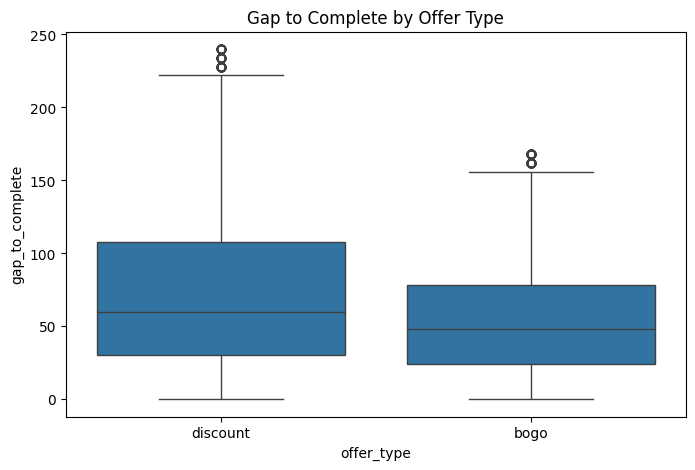

In [18]:
#when
tmp = df[df['gap_to_complete'].notna()].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=tmp, x='offer_type', y='gap_to_complete')
plt.title('Gap to Complete by Offer Type')
plt.show()

In [19]:
import matplotlib.font_manager as fm

for font in fm.findSystemFonts():
    if 'Malgun' in font:
        print(font)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 맑은고딕 폰트 경로 직접 지정 (Windows)
font_path = "C:/Windows/Fonts/malgun.ttf"
font = fm.FontProperties(fname=font_path)

plt.rc('font', family=font.get_name())
plt.rcParams['axes.unicode_minus'] = False

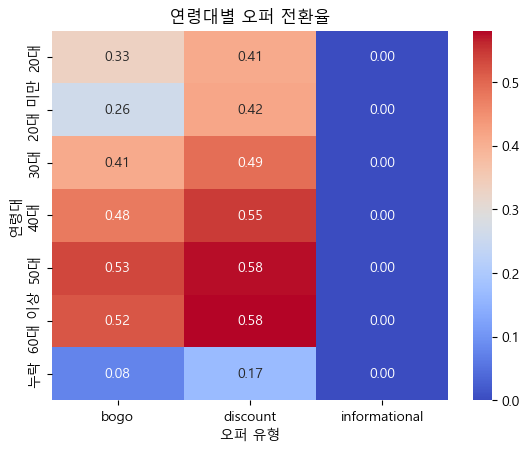

In [20]:
pivot = df.pivot_table(
    index='age_group',
    columns='offer_type',
    values='is_completed',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('연령대별 오퍼 전환율')
plt.xlabel('오퍼 유형')
plt.ylabel('연령대')
plt.show()


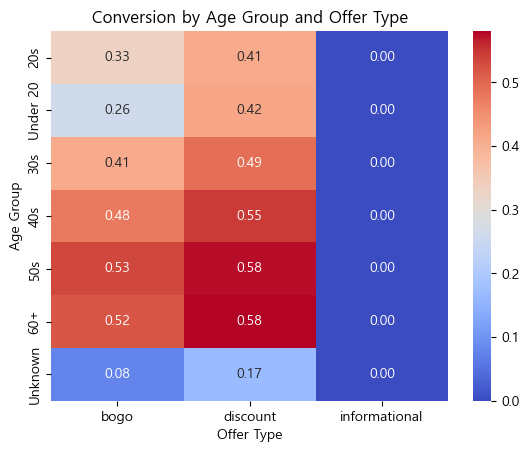

In [21]:
pivot2 = pivot.copy()
pivot2.index = ['20s', 'Under 20', '30s', '40s', '50s', '60+', 'Unknown']

sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Conversion by Age Group and Offer Type')
plt.xlabel('Offer Type')
plt.ylabel('Age Group')
plt.show()

In [22]:
df.groupby(['offer_type'])['is_completed'].mean()

offer_type
bogo             0.421797
discount         0.487791
informational    0.000000
Name: is_completed, dtype: float64

In [23]:
df.groupby(['reward_ratio'])['is_completed'].mean()

reward_ratio
0.000000    0.000000
0.200000    0.524917
0.250000    0.229885
0.428571    0.630876
1.000000    0.421797
Name: is_completed, dtype: float64

In [24]:
df.groupby('reward_ratio').agg(
    n=('customer_id', 'count'),
    conversion_rate=('is_completed', 'mean')
).sort_values('conversion_rate', ascending=False)

,n,conversion_rate
reward_ratio,,
0.428571,6892,0.630876
0.200000,12722,0.524917
1.000000,25939,0.421797
0.250000,5655,0.229885
0.000000,15235,0.000000


In [25]:
df.groupby('difficulty')['is_completed'].mean()

difficulty
0.0     0.000000
5.0     0.456799
7.0     0.630876
10.0    0.455232
20.0    0.229885
Name: is_completed, dtype: float64

In [26]:
df.groupby('reward')['is_completed'].mean()

reward
0.0     0.000000
2.0     0.524917
3.0     0.630876
5.0     0.385344
10.0    0.390217
Name: is_completed, dtype: float64

In [27]:
df.groupby('offer_strength')['is_completed'].mean()

offer_strength
-15.0    0.229885
-8.0     0.524917
-4.0     0.630876
 0.0     0.265726
Name: is_completed, dtype: float64

In [28]:
pivot_who_why = df.pivot_table(
    index='age_group',
    columns='offer_type',
    values='is_completed',
    aggfunc='mean'
)
pivot_who_why

offer_type,bogo,discount,informational
age_group,,,
20대,0.331429,0.408638,0.0
20대 미만,0.262997,0.415493,0.0
30대,0.410323,0.490314,0.0
40대,0.477166,0.545349,0.0
50대,0.533034,0.575337,0.0
60대 이상,0.518424,0.580516,0.0
누락,0.076265,0.167365,0.0


In [29]:
df.pivot_table(
    index='gender',
    columns='offer_type',
    values='is_completed',
    aggfunc='mean'
)

offer_type,bogo,discount,informational
gender,,,
F,0.595869,0.628244,0.0
M,0.402181,0.488993,0.0
O,0.627063,0.630225,0.0
Unknown,0.076265,0.167365,0.0


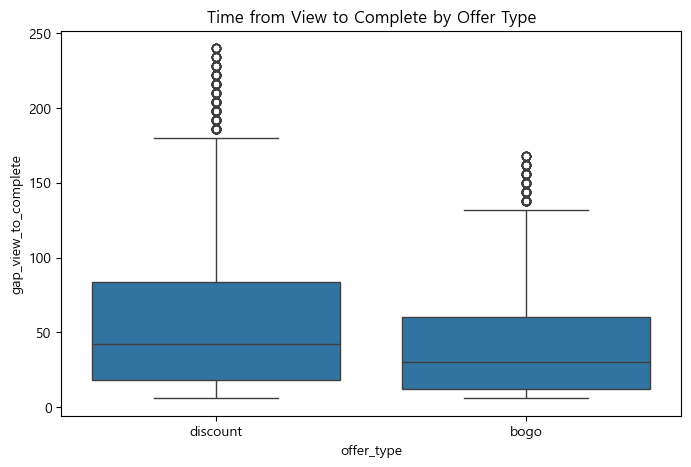

In [30]:
tmp2 = df[df['gap_view_to_complete'].notna()].copy()

plt.figure(figsize=(8,5))
sns.boxplot(data=tmp2, x='offer_type', y='gap_view_to_complete')
plt.title('Time from View to Complete by Offer Type')
plt.show()

In [31]:
summary = {
    'WHO_best_age_group': df.groupby('age_group')['is_completed'].mean().idxmax(),
    'WHO_best_gender': df.groupby('gender')['is_completed'].mean().idxmax(),
    'WHY_best_offer_type': df.groupby('offer_type')['is_completed'].mean().idxmax(),
}
summary

{'WHO_best_age_group': '50대',
 'WHO_best_gender': 'O',
 'WHY_best_offer_type': 'discount'}

In [32]:
pivot_full = df.pivot_table(
    index=['age_group', 'gender'],
    columns='offer_type',
    values='is_completed',
    aggfunc='mean'
)
pivot_full = pivot_full.round(3)
pivot_full = pivot_full.sort_index()

pivot_full

offer_type          bogo  discount  informational
age_group gender                                 
20대       F        0.505     0.545            0.0
          M        0.264     0.365            0.0
          O        0.375     0.296            0.0
20대 미만    F        0.420     0.340            0.0
          M        0.221     0.433            0.0
30대       F        0.577     0.598            0.0
          M        0.330     0.442            0.0
          O        0.611     0.606            0.0
40대       F        0.588     0.623            0.0
          M        0.410     0.496            0.0
          O        0.722     0.729            0.0
50대       F        0.624     0.646            0.0
          M        0.462     0.521            0.0
          O        0.662     0.680            0.0
60대 이상    F        0.603     0.641            0.0
          M        0.442     0.528            0.0
          O        0.616     0.632            0.0
누락        Unknown  0.076     0.167            0.0

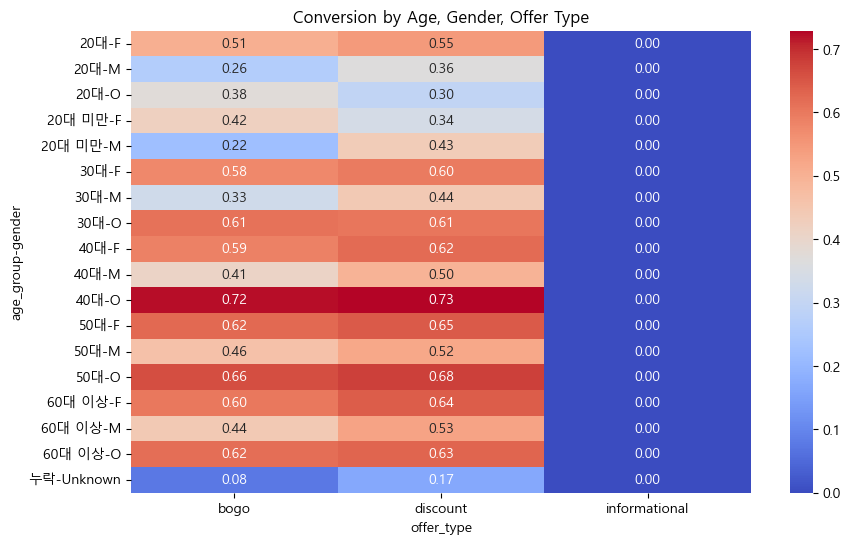

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot_full, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Conversion by Age, Gender, Offer Type')
plt.show()

In [47]:
count_pivot = df.pivot_table(
    index = ['age_group', 'gender'],
    columns='offer_type',
    values='customer_id',
    aggfunc='count'
)

count_pivot

offer_type         bogo  discount  informational
age_group gender                                
20대       F         574       521            356
          M        1502      1559            810
          O          24        27             11
20대 미만    F          69        53             45
          M         258       231            154
30대       F         716       682            470
          M        1573      1608            891
          O          36        33             17
40대       F        1268      1219            735
          M        2291      2162           1273
          O          54        59             39
50대       F        2160      2105           1442
          M        2879      2864           1703
          O          77        75             57
60대 이상    F        3975      3705           2490
          M        4516      4431           2736
          O         112       117             71
누락        Unknown  3855      3818           1935

In [48]:
result = df.groupby(
    ['age_group', 'gender', 'offer_type']
).agg(
    n=('customer_id', 'count'),
    conversion_rate=('is_completed', 'mean')
).reset_index()

result.sort_values('conversion_rate', ascending=False).head(10)

,age_group,gender,offer_type,n,conversion_rate
31,40대,O,discount,59,0.728814
30,40대,O,bogo,54,0.722222
40,50대,O,discount,75,0.680000
39,50대,O,bogo,77,0.662338
34,50대,F,discount,2105,0.645606
43,60대 이상,F,discount,3705,0.641296
49,60대 이상,O,discount,117,0.632479
33,50대,F,bogo,2160,0.623611
25,40대,F,discount,1219,0.623462
48,60대 이상,O,bogo,112,0.616071


In [50]:
df.groupby('completed_without_prior_view').agg(
    n=('customer_id', 'count'),
    completion_rate=('is_completed', 'mean')
)

,n,completion_rate
completed_without_prior_view,,
False,66443,0.35018
